# FINAL PROJECT

In [1]:
import matplotlib.pyplot as plt
import numpy as np

import tidy3d as td
import gplugins.tidy3d as gt
import gplugins.tidy3d.materials as mat
from gplugins import plot
from gplugins.common.config import PATH

from upvfab_design_tools import MMI_EME, DC_EME

nm = 1e-3
wavelength = np.linspace(1500, 1600) * nm
f = td.C_0 / wavelength

## MMI'S (cross section)

/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

11:29:43 CEST WARNING: The group index was not computed. To calculate group     
              index, pass 'group_index_step = True' in the 'ModeSpec'.          

2026-04-28 11:29:43.353 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_4f022be925d3e37c.npz.
Fracción TE: [0.99998653 0.99994507]


array([1.67848654+7.77027397e-05j, 1.67345211+7.81064335e-05j])

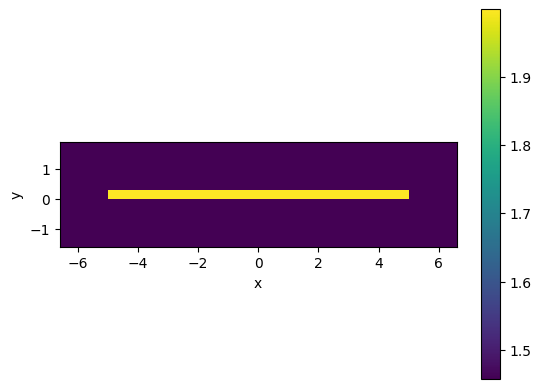

In [2]:
mmi_body_w = 10
lambda_c = 1.55

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=2, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.2, # Parameters of the grid
    grid_resolution=20, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.plot_index()
pol = mmi_body_waveguide.fraction_te
print(f'Fracción TE: {pol}')
mmi_body_waveguide.n_eff

In [3]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

153.93996417502748


### Mesh 

[20. 30. 40. 50. 60. 70. 80.]
2026-04-28 11:37:29.818 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_24c33edd2fbe1881.npz.
2026-04-28 11:37:29.822 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_39b273c5448a402f.npz.
2026-04-28 11:37:29.825 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2c40f9ab444edd2b.npz.
2026-04-28 11:37:29.827 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_1f4d5bd178843423.npz.
2026-04-28 11:37:29.830 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c4b58fd0c9d996c5.npz.
2026-04-28 11:37:29.832 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f5ce037f102dc7b6.npz.
2026-04-28 11:37:29.835 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_b8b190484d25a0db.npz.


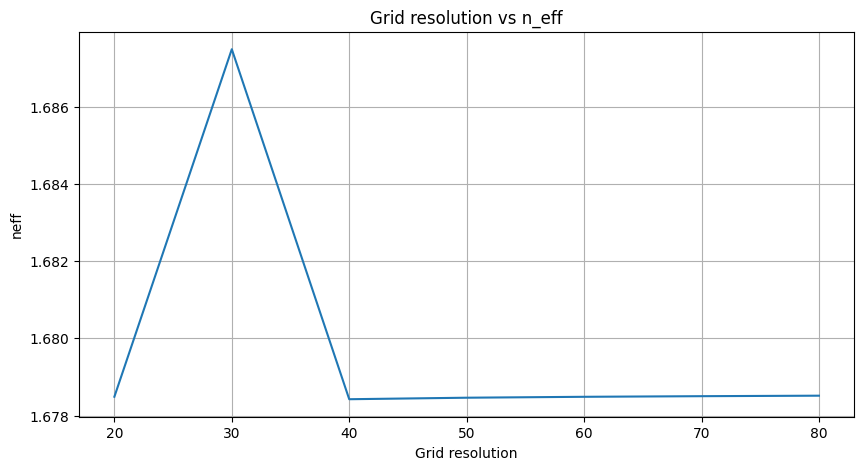

In [7]:
n_steps = 7
grid_resolution = np.linspace(20,80,n_steps)
res_neff = []
print(grid_resolution)

for i in range(n_steps): 
    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=300*nm, # MMI Body height 
        slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=1.2, # Parameters of the grid
        grid_resolution=grid_resolution[i], # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= mmi_body_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"Grid resolution vs n_eff")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.grid()
plt.plot(grid_resolution, res_neff)

2026-04-28 11:32:33.293 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_2c40f9ab444edd2b.npz.


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-04-28 11:32:41.404 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_22a3ad30c6ca35bf.npz.


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-04-28 11:32:48.709 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_7329da91ae8f46b5.npz.


...

2026-04-28 11:33:00.692 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_13194a9bce33ff22.npz.


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-04-28 11:33:07.817 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_162c8f788cee3692.npz.


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-04-28 11:33:14.896 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_31d979412394fa4b.npz.


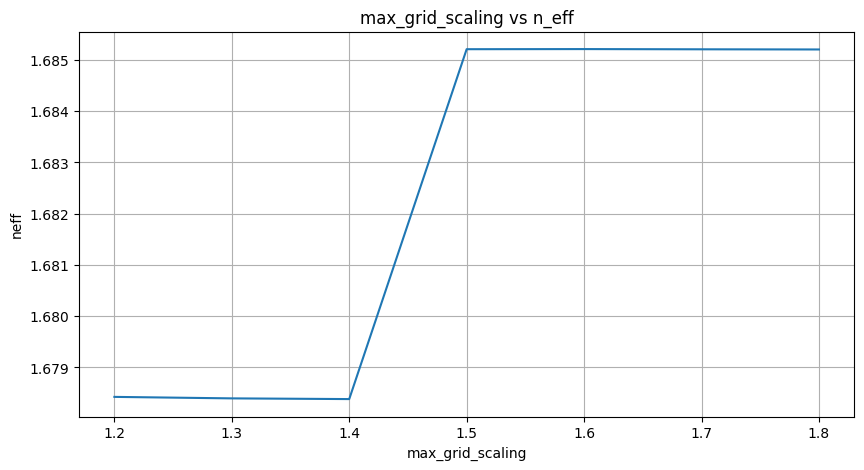

In [5]:
n_steps = 7
max_grid_scaling = np.linspace(1.2,1.8,n_steps)
res_neff = []


for i in range(n_steps): 
    mmi_body_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=mmi_body_w, # MMI Body width
        core_thickness=300 * nm, # MMI Body height 
        slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find - Higher than before! It's a multimode section
        max_grid_scaling=max_grid_scaling[i], # Parameters of the grid
        grid_resolution=40, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= mmi_body_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"max_grid_scaling vs n_eff")
plt.xlabel("max_grid_scaling")
plt.ylabel("neff")
plt.grid()
plt.plot(max_grid_scaling, res_neff)

/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-04-28 11:38:08.850 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_ca3f48c766921472.npz.
Fracción TE: [0.99998722 0.99994792]


array([1.6784221 +7.77902067e-05j, 1.67338367+7.81958045e-05j])

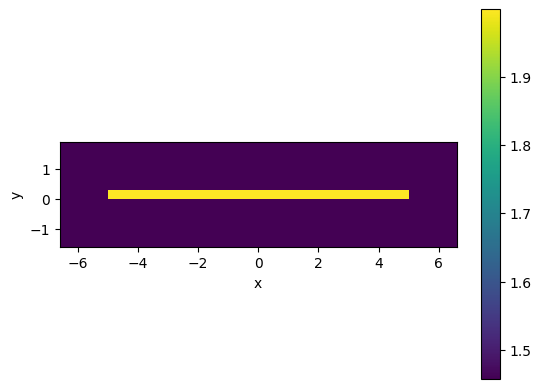

In [8]:
mmi_body_w = 10
lambda_c = 1.55

mmi_body_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=mmi_body_w, # MMI Body width
    core_thickness=300 * nm, # MMI Body height 
    slab_thickness=0, # For shallow waveguides - Set to 0 if its a deep-etched waveguides.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=2, # Targeted number of modes to find - Higher than before! It's a multimode section
    max_grid_scaling=1.2, # Parameters of the grid
    grid_resolution=40, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

mmi_body_waveguide.plot_index()
pol = mmi_body_waveguide.fraction_te
print(f'Fracción TE: {pol}')
mmi_body_waveguide.n_eff

In [9]:
d_n_eff = mmi_body_waveguide.n_eff[0].real -  mmi_body_waveguide.n_eff[1].real

L_pi = 0.5*lambda_c/(d_n_eff)

print (L_pi)

153.81760957037494


## MMI 95:05 (rectangular ;( )

In [53]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 10  # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width
m.wg_width=3
m.MMI_num_modes = 40 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
m.VERBOSE = True
m.find_all_modes()

# 2) Get the L_pi 
L_pi_eme = m.get_L_pi()


[Mode(k: (6.526105164378319+0j), n_eff:(1.6099259388749516+0j)), Mode(k: (6.505221506434929+0j), n_eff:(1.6047741459180789+0j)), Mode(k: (6.4703427638849424+0j), n_eff:(1.5961699032753058+0j)), Mode(k: (6.421370963511217+0j), n_eff:(1.5840890419178446+0j)), Mode(k: (6.358197020260405+0j), n_eff:(1.5685046516362353+0j)), Mode(k: (6.280752339927786+0j), n_eff:(1.549399810915018+0j)), Mode(k: (6.189133233715225+0j), n_eff:(1.5267982787801628+0j)), Mode(k: (6.172639472943731+0j), n_eff:(1.522729430266877+0j)), Mode(k: (6.152654706011708+0j), n_eff:(1.517799384879032+0j)), Mode(k: (6.1193865160779435+0j), n_eff:(1.5095924497217303+0j)), Mode(k: (6.083989794704313+0j), n_eff:(1.5008604267991477+0j)), Mode(k: (6.07296178580335+0j), n_eff:(1.4981399254991206+0j)), Mode(k: (6.0137697296955945+0j), n_eff:(1.4835378276010713+0j)), Mode(k: (5.968543226735516+0j), n_eff:(1.4723808942685435+0j))]
Wavelength 1.55  µm
---------------------------------------------
Core refractive index: 1.9983425877143

/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


n_MODES= 9
Lπ 2D = 150.43 µm
[Mode(k: (6.526105164378319+0j), n_eff:(1.6099259388749516+0j)), Mode(k: (6.505221506434929+0j), n_eff:(1.6047741459180789+0j)), Mode(k: (6.4703427638849424+0j), n_eff:(1.5961699032753058+0j)), Mode(k: (6.421370963511217+0j), n_eff:(1.5840890419178446+0j)), Mode(k: (6.358197020260405+0j), n_eff:(1.5685046516362353+0j)), Mode(k: (6.280752339927786+0j), n_eff:(1.549399810915018+0j)), Mode(k: (6.189133233715225+0j), n_eff:(1.5267982787801628+0j)), Mode(k: (6.172639472943731+0j), n_eff:(1.522729430266877+0j)), Mode(k: (6.152654706011708+0j), n_eff:(1.517799384879032+0j)), Mode(k: (6.1193865160779435+0j), n_eff:(1.5095924497217303+0j)), Mode(k: (6.083989794704313+0j), n_eff:(1.5008604267991477+0j)), Mode(k: (6.07296178580335+0j), n_eff:(1.4981399254991206+0j)), Mode(k: (6.0137697296955945+0j), n_eff:(1.4835378276010713+0j)), Mode(k: (5.968543226735516+0j), n_eff:(1.4723808942685435+0j))]


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


en esta parte dnd tengo que decidir donde pongo las guías etc, en el paper de pennings pone que mejor usar la general para el 2x2 que la paired, si no es guiado weakly

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3009 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment 0.0000
IO wg width 3.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 1.0000
Total OUT power: 0.9911
Excess loss [dB] =  0.0389
------------------------
Power over OUTs:  ['0.0001', '0.9910']
Ratio over OUTs ['0.0001', '0.9999']


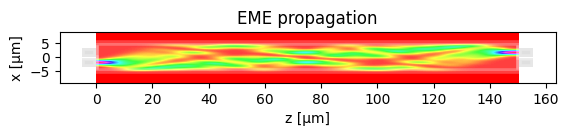

In [56]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)

m.n_IN =  2 # STUDENT
m.n_OUT = 2 # STUDENT
m.dL_MMI = 0
dy = 0
# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([-1.8, 1.8]) # STUDENT
m.OUT_WVG_positions =np.array([-1.8, 1.8])# STUDENT

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi_eme


# Run propagation
m.propagation()

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3229 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment 11.0000
IO wg width 3.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 1.0000
Total OUT power: 0.6464
Excess loss [dB] =  1.8948
------------------------
Power over OUTs:  ['0.0294', '0.6170']
Ratio over OUTs ['0.0455', '0.9545']


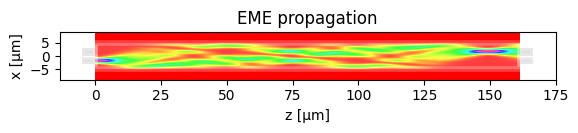

In [72]:
#más optimizado
dy = -0.1

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([-1.8, 1.8]) + np.array([-dy, dy]) # STUDENT
m.OUT_WVG_positions = np.array([-1.8, 1.8]) + np.array([-dy, dy]) # STUDENT4

# MMI length (check class slides for type of MMI)
m.dL_MMI = 11 # STUDENT

# Run propagation
m.propagation()

/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/5252 [00:00<?, ?it/s]

------- Pameters -------
MMI length 245.9723
MMI length increment 16.6500
IO wg width 2.4000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9985
Total OUT power: 0.4420
Excess loss [dB] =  3.5463
------------------------
Power over OUTs:  ['0.0312', '0.4108']
Ratio over OUTs ['0.0706', '0.9294']


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


...

------- Pameters -------
MMI length 245.9723
MMI length increment 16.6500
IO wg width 2.7000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9987
Total OUT power: 0.5243
Excess loss [dB] =  2.8045
------------------------
Power over OUTs:  ['0.0261', '0.4982']
Ratio over OUTs ['0.0497', '0.9503']


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/25 [00:00<?, ?it/s]

  0%|          | 0/5252 [00:00<?, ?it/s]

------- Pameters -------
MMI length 245.9723
MMI length increment 16.6500
IO wg width 2.8000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9988
Total OUT power: 0.5509
Excess loss [dB] =  2.5892
------------------------
Power over OUTs:  ['0.0245', '0.5264']
Ratio over OUTs ['0.0445', '0.9555']


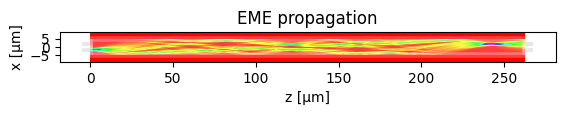

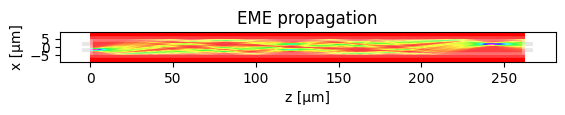

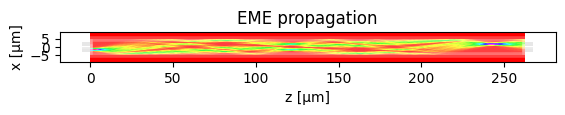

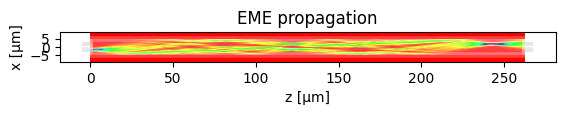

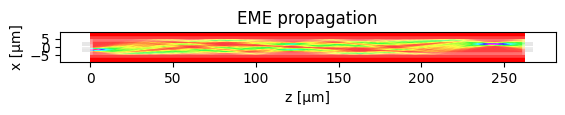

In [ ]:
widths = [2.4, 2.5, 2.6, 2.7, 2.8]
mmi_Width = 10

for dw in widths:
    m = MMI_EME() 
    m.MMI_width = mmi_Width
    m.wg_width=dw
    m.MMI_num_modes = 30
    
    m.find_all_modes()
    L_pi_eme = m.get_L_pi()

    m.n_IN = 2 
    m.n_OUT = 2 
    
    dy = 0
    m.IN_WVG_positions = np.array([-1.68, 1.68]) + np.array([-dy, dy])
    m.OUT_WVG_positions = np.array([-1.68, 1.68]) + np.array([-dy, dy])
    
    m.L_MMI = L_pi_eme
    m.dL_MMI = 16.65
    
    m.propagation()

## MMI 33:33:33

In [38]:
# Simulation flow for MMI Couplers
# Define your geometrical parameters here
mmi_Width = 10  # Student. Body width

m = MMI_EME() # Here you instantiate a MMI to be simulated with the Eigen-mode expansion (EME) algorithm.
m.MMI_width = mmi_Width

m.wg_width=2.6
m.MMI_num_modes = 40 # Number of modes to be calculated. Here, the higher, the better since we are going to calculate
                    # the propagation based on the mode decomposition. 

# 1) Compute de MMI body modes - Only execute whenever a geometrical parameter is changed. Takes time to find the modes. 
#m.VERBOSE = True
m.find_all_modes()

# 2) Get the L_pi 
L_pi_eme = m.get_L_pi()
print(L_pi_eme)

/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


150.4330640783897


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3009 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment 0.0000
IO wg width 2.6000
IO wg width increment 0.0000
------------------------
Total power IN coupled 1.0007
Total OUT power: 0.7374
Excess loss [dB] =  1.3227
------------------------
Power over OUTs:  ['0.1382', '0.2615', '0.3377']
Ratio over OUTs ['0.1874', '0.3547', '0.4580']


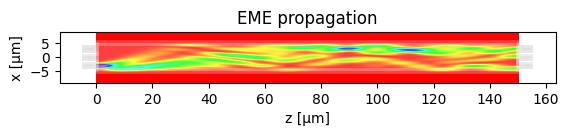

In [39]:
# IMPORTANT!!! 
# # If you DON'T change neither the MMI width 
# nor input/output waveguide widths
# YOU CAN RUN the lines below as many times as you wish
# (SAVES TIME)

# 3) Configure MMI
# # MMI I/O number (check class slides for type of MMI)

m.dL_MMI = 0
dy = 0
m.n_IN = 3
m.n_OUT = 3

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([-3, 0, 3])
m.OUT_WVG_positions =np.array([-3, 0,  3])

# MMI length (check class slides for type of MMI)
m.L_MMI = L_pi_eme


# Run propagation
m.propagation()

  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2989 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment -1.0000
IO wg width 2.6000
IO wg width increment 0.0000
------------------------
Total power IN coupled 1.0014
Total OUT power: 1.0000
Excess loss [dB] =  0.0001
------------------------
Power over OUTs:  ['0.3301', '0.3239', '0.3460']
Ratio over OUTs ['0.3301', '0.3239', '0.3461']


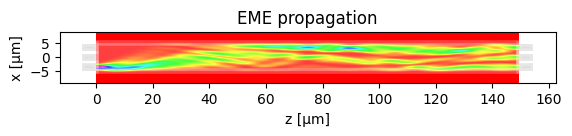

In [ ]:
# MEJOR COMBINACIÓN EN CUANTO A PÉRDIDAS !!!!!
dy = 0.5

# MMI I/O waveguide positions (check class slides for type of MMI)
m.IN_WVG_positions = np.array([-3, 0, 3]) + np.array([-dy, 0, dy]) # STUDENT
m.OUT_WVG_positions = np.array([-3, 0, 3]) + np.array([-dy,0, dy]) # STUDENT4


# MMI length (check class slides for type of MMI)
m.dL_MMI = -1 # STUDENT

# Run propagation
m.propagation()

/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2999 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment -0.5000
IO wg width 2.4000
IO wg width increment 0.0000
------------------------
Total power IN coupled 1.0014
Total OUT power: 0.9980
Excess loss [dB] =  0.0085
------------------------
Power over OUTs:  ['0.3287', '0.3230', '0.3464']
Ratio over OUTs ['0.3293', '0.3236', '0.3470']


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


...

------- Pameters -------
MMI length 150.4331
MMI length increment -0.5000
IO wg width 2.7000
IO wg width increment 0.0000
------------------------
Total power IN coupled 1.0011
Total OUT power: 0.9992
Excess loss [dB] =  0.0035
------------------------
Power over OUTs:  ['0.3310', '0.3247', '0.3435']
Ratio over OUTs ['0.3312', '0.3250', '0.3438']


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/2999 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment -0.5000
IO wg width 2.8000
IO wg width increment 0.0000
------------------------
Total power IN coupled 1.0006
Total OUT power: 0.9986
Excess loss [dB] =  0.0061
------------------------
Power over OUTs:  ['0.3311', '0.3251', '0.3424']
Ratio over OUTs ['0.3316', '0.3255', '0.3429']


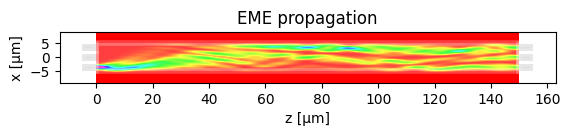

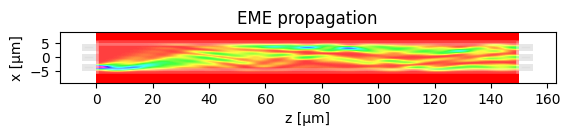

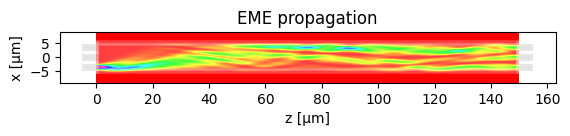

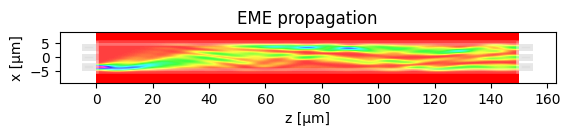

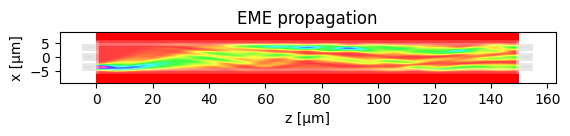

In [35]:
widths = [2.4, 2.5, 2.6, 2.7, 2.8]
mmi_Width = 10

for dw in widths:
    m = MMI_EME() 
    m.MMI_width = mmi_Width
    m.wg_width=dw
    m.MMI_num_modes = 30
    
    m.find_all_modes()
    L_pi_eme = m.get_L_pi()

    m.n_IN = 3
    m.n_OUT = 3
    
    dy = 0.5
    m.IN_WVG_positions = np.array([-3, 0, 3]) + np.array([-dy, 0, dy])
    m.OUT_WVG_positions = np.array([-3, 0, 3]) + np.array([-dy, 0, dy])
    
    m.L_MMI = L_pi_eme
    m.dL_MMI = -0.5
    
    m.propagation()

/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3041 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment 1.6000
IO wg width 2.9000
IO wg width increment 0.0000
------------------------
Total power IN coupled 1.0001
Total OUT power: 0.9764
Excess loss [dB] =  0.1037
------------------------
Power over OUTs:  ['0.3294', '0.3213', '0.3257']
Ratio over OUTs ['0.3374', '0.3291', '0.3336']


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/skfem/assembly/form/linear_form.py:44: ComplexWarning: Casting complex values to real discards the imaginary part
  data[ixs] = self._kernel(vbasis.basis[i], w, dx)


  0%|          | 0/9 [00:00<?, ?it/s]

  0%|          | 0/3041 [00:00<?, ?it/s]

------- Pameters -------
MMI length 150.4331
MMI length increment 1.6000
IO wg width 3.0000
IO wg width increment 0.0000
------------------------
Total power IN coupled 0.9995
Total OUT power: 0.9791
Excess loss [dB] =  0.0917
------------------------
Power over OUTs:  ['0.3296', '0.3238', '0.3257']
Ratio over OUTs ['0.3367', '0.3307', '0.3326']


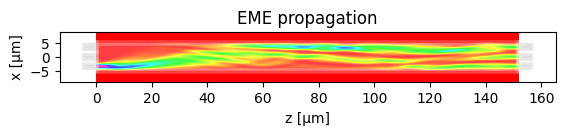

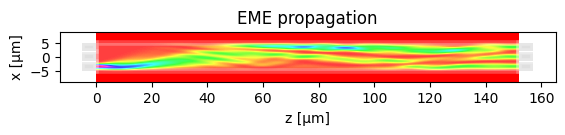

In [23]:
widths = [2.9, 3]
mmi_Width = 10

for dw in widths:
    m = MMI_EME() 
    m.MMI_width = mmi_Width
    m.wg_width=dw
    m.MMI_num_modes = 30
    
    m.find_all_modes()
    L_pi_eme = m.get_L_pi()

    m.n_IN = 3
    m.n_OUT = 3
    
    dy = 0.5
    m.IN_WVG_positions = np.array([-3, 0, 3]) + np.array([-dy, 0, dy])
    m.OUT_WVG_positions = np.array([-3, 0, 3]) + np.array([-dy, 0, dy])
    
    m.L_MMI = L_pi_eme
    m.dL_MMI = 1.6
    
    m.propagation()

# GUÍA DEEP

2026-04-28 12:08:36.299 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_da410acb79a54d73.npz.
Índice efectivo: <matplotlib.collections.QuadMesh object at 0x7604807332f0>
Fracción TE: [0.98781879]


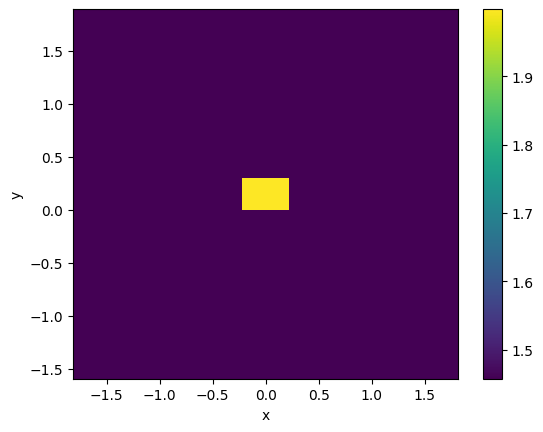

In [29]:
lambda_c = 1.55

deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450 * nm, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find 
    max_grid_scaling=1.4, # Parameters of the grid 
    grid_resolution=50, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

neff = deep_waveguide.plot_index()
pol = deep_waveguide.fraction_te

print(f'Índice efectivo: {neff}')
print(f'Fracción TE: {pol}')

#### Group index

In [20]:
wl = np.linspace(1.5,1.6, 200)

deep_waveguide = gt.modes.Waveguide(
    # Geometrical Parameters
    core_width=450 * nm, # Waveguide width
    core_thickness=300 * nm, # Waveguide height 
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=wl, # Wavelength to simulate
    num_modes=1, # Targeted number of modes to find 
    max_grid_scaling=1.4, # Parameters of the grid 
    grid_resolution=50, # Parameters of the grid
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
)

neff = deep_waveguide.n_eff.real




ng = neff - wl * np.gradient(neff, wl)

print(ng)

/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-04-28 11:58:14.429 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_9815c65685d16075.npz.
[1.67142268 1.67127905 1.67099199 1.67070531 1.67041901 1.6701331
 1.66984757 1.66956242 1.66927765 1.66899327 1.66870928 1.66842567
 1.66814244 1.6678596  1.66757714 1.66729507 1.66701338 1.66673208
 1.66645116 1.66617063 1.66589048 1.66561072 1.66533135 1.66505237
 1.66477377 1.66449555 1.66421773 1.66394029 1.66366323 1.66338657
 1.66311029 1.6628344  1.6625589  1.66228378 1.66200906 1.66173472
 1.66146077 1.66118721 1.66091403 1.66064125 1.66036885 1.66009685
 1.65982523 1.659554   1.65928316 1.65901271 1.65874265 1.65847298
 1.65820369 1.6579348  1.6576663  1.65739819 1.65713046 1.65686313
 1.65659619 1.65632963 1.65606347 1.6557977  1.65553232 1.65526732
 1.65500272 1.65473851 1.65447469 1.65421126 1.65394822 1.65368557
 1.65342332 1.65316145 1.65289997 1.65263889 1.6523782  1.65211789
 1.65185798 1.65159846 1.65133933 1.65108059 1.65082224 1.65056428
 1.6

In [21]:
# índice de grupo a wl=1.55
idx = np.argmin(abs(wl - 1.55))
ng_wl0 = ng[idx]
print(ng_wl0)

1.6449881559393404


In [23]:
FSR = 1e-5 #um = 10pm
wl0 = 1.55

AL = (wl0**2)/(ng_wl0*FSR)

print(f'AL = {AL}')

AL = 146049.68378195382


### Mesh study

2026-04-28 11:49:12.744 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_3054185e9aaac215.npz.
2026-04-28 11:49:12.746 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f20830055458230b.npz.
2026-04-28 11:49:12.750 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_c5fc37ff90a37d04.npz.
2026-04-28 11:49:12.756 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_abb4674a5e4039d0.npz.
2026-04-28 11:49:12.758 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_dd3ebf0ba81f363b.npz.
2026-04-28 11:49:12.762 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_7a64c35c7147ef2a.npz.
2026-04-28 11:49:12.763 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_f6f9ebf31caba6af.npz.


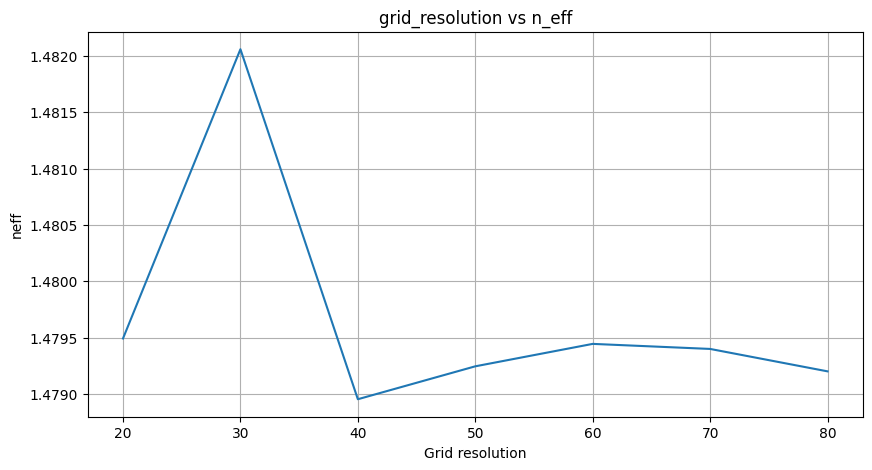

In [19]:
n_steps = 7
grid_resolution = np.linspace(20,80,n_steps)
res_neff = []

for i in range(n_steps): 
    deep_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=450 * nm, # Waveguide width
        core_thickness=300* nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find 
        max_grid_scaling=1.2, # Parameters of the grid 
        grid_resolution=grid_resolution[i], # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= deep_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"grid_resolution vs n_eff")
plt.xlabel("Grid resolution")
plt.ylabel("neff")
plt.grid()
plt.plot(grid_resolution, res_neff)

2026-04-28 11:48:05.116 | INFO     | gplugins.tidy3d.modes:_data:266 - load data from .cache/Waveguide_abb4674a5e4039d0.npz.


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-04-28 11:48:07.767 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_e685e1dfc0c26ef5.npz.


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-04-28 11:48:09.704 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_da410acb79a54d73.npz.


...

2026-04-28 11:48:15.198 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_74788490e32be03a.npz.


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-04-28 11:48:17.143 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_ba00674b63a803c2.npz.


/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:14: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxf = sp.csr_matrix(sp.diags([-1, 1], [0, 1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/lib/python3.12/site-packages/tidy3d/components/mode/derivatives.py:27: FutureWarning: Input has data type int64, but the output has been cast to float64.  In the future, the output data type will match the input. To avoid this warning, set the `dtype` parameter to `None` to have the output dtype match the input, or set it to the desired output data type.
  dxb = sp.csr_matrix(sp.diags([1, -1], [0, -1], shape=(Nx, Nx)))
/home/maria_romero/pic-upv-lab5-finalproject/.venv/li

2026-04-28 11:48:19.243 | INFO     | gplugins.tidy3d.modes:_data:306 - store data into .cache/Waveguide_b62c9af2cee013ed.npz.


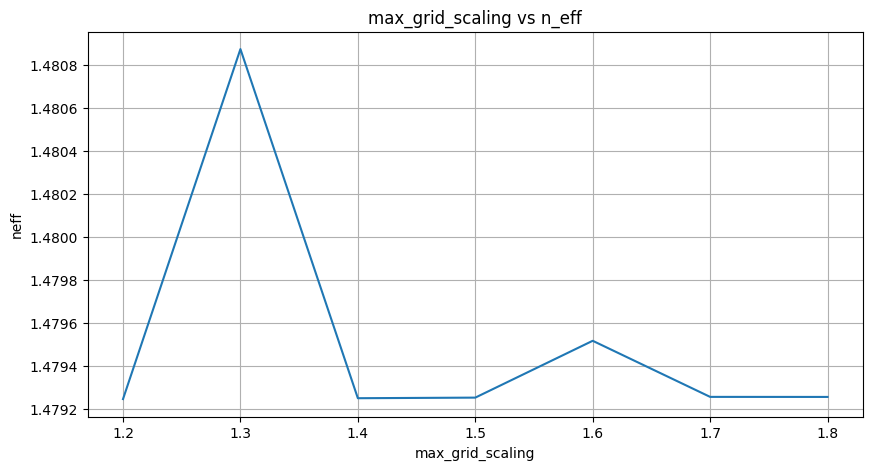

In [18]:
lambda_c = 1.55
n_steps = 7
max_grid_scaling = np.linspace(1.2,1.8,n_steps)
res_neff = []


for i in range(n_steps): 
    deep_waveguide = gt.modes.Waveguide(
        # Geometrical Parameters
        core_width=450 * nm, # Waveguide width
        core_thickness=300 * nm, # Waveguide height 
        slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
        # Materials
        core_material='sin', #  Material of the waveguide
        clad_material='sio2', # Surrounding material
        # Modesolver Parameters
        wavelength=lambda_c, # Wavelength to simulate
        num_modes=1, # Targeted number of modes to find 
        max_grid_scaling=max_grid_scaling[i], # Parameters of the grid 
        grid_resolution=50, # Parameters of the grid
        cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
        precision='double',
    )

    n_eff= deep_waveguide.n_eff.real
    res_neff.append(n_eff)

res_neff=np.array(res_neff)

plt.figure(figsize=(10, 5))
plt.title(f"max_grid_scaling vs n_eff")
plt.xlabel("max_grid_scaling")
plt.ylabel("neff")
plt.grid()
plt.plot(max_grid_scaling, res_neff)

Decido: grid_resolution = 50 y max_grid_scaling = 1.4

# GAP STUDY (por hacer) : lab 02 (me lo ha pasado sergi por outlook)

In [ ]:
#espiral (decidir gap o hacer barrido etc)

lambda_c = 1.5

dcoupler_cs = gt.modes.WaveguideCoupler(
    # Geometrical Parameters
    core_width=(0.45, 0.45), # Waveguide width
    slab_thickness=0 * nm, # For shallow waveguides - Set to 0 if its a deep-etched waveguide.
    core_thickness=300 * nm, # Waveguide height 
    gap=600* nm,
    # Materials
    core_material='sin', #  Material of the waveguide
    clad_material='sio2', # Surrounding material
    # Modesolver Parameters
    wavelength=lambda_c, # Wavelength to simulate
    num_modes=4, # Number of modes to find
    cache_path='.cache/', # Important! In order to save simulation time, set your cache Path!
    precision='double',
    max_grid_scaling=1.2, # Parameters of the grid
    grid_resolution=20 # Parameters of the grid
)

dcoupler_neff = dcoupler_cs.n_eff
#print(f'Índices efectivos: {dcoupler_neff}')

te_frac = dcoupler_cs.fraction_te
print(f'Fracción TE: {te_frac}')

L_pi_TE = 0.5*lambda_c/(dcoupler_neff[0].real-dcoupler_neff[1].real)
print(f'Longitud de Batido TE: {L_pi_TE} um')

#L_pi_TM =  0.5*lambda_c/(dcoupler_neff[2].real-dcoupler_neff[3].real)
#print(f'Longitud de Batido TM: {L_pi_TM} um')

L = np.linspace(0, 250, 250)

K = np.array(250)
for i in range(250): 
    K= np.sin((1/2)*np.pi*(L/L_pi_TE))**2

plt.plot(L/L_pi_TE, K)
plt.title('L/L_pi vs K')
plt.xlabel('L/L_pi')
plt.ylabel('K')
plt.grid()
plt.show()